# Week 08: Data Analysis Basics

                **Focus:** Inspect a dataset properly before modelling with head, info, describe, value counts, plots, and a train-test split.

                **Learning objectives**
                - Profile a dataset with pandas
- Spot missing values and type issues
- Create a reproducible split

                **Source materials:** Data Analysis.pptx, Sample_Data_Analysis.pdf, housing.csv, california_housing_train (1).csv, california_housing_test.csv

## Key Highlights

- The standard first pass over a new dataset
- Quick visual checks for distributions and data issues
- Why train-test splits should happen early

## Project setup

In [1]:
from pathlib import Path
import sys

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "requirements.txt").exists() and (candidate / "weeks").exists():
            return candidate
    return current

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

ROOT


WindowsPath('F:/Recovery Asus TFug/Master Degree/1º semester/Python Notebooks and Scripting/Python Notebook/ct7201-guide')

## Load and inspect housing

In [2]:
import pandas as pd

housing = pd.read_csv(ROOT / "data" / "housing" / "housing.csv")
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Profile and split

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

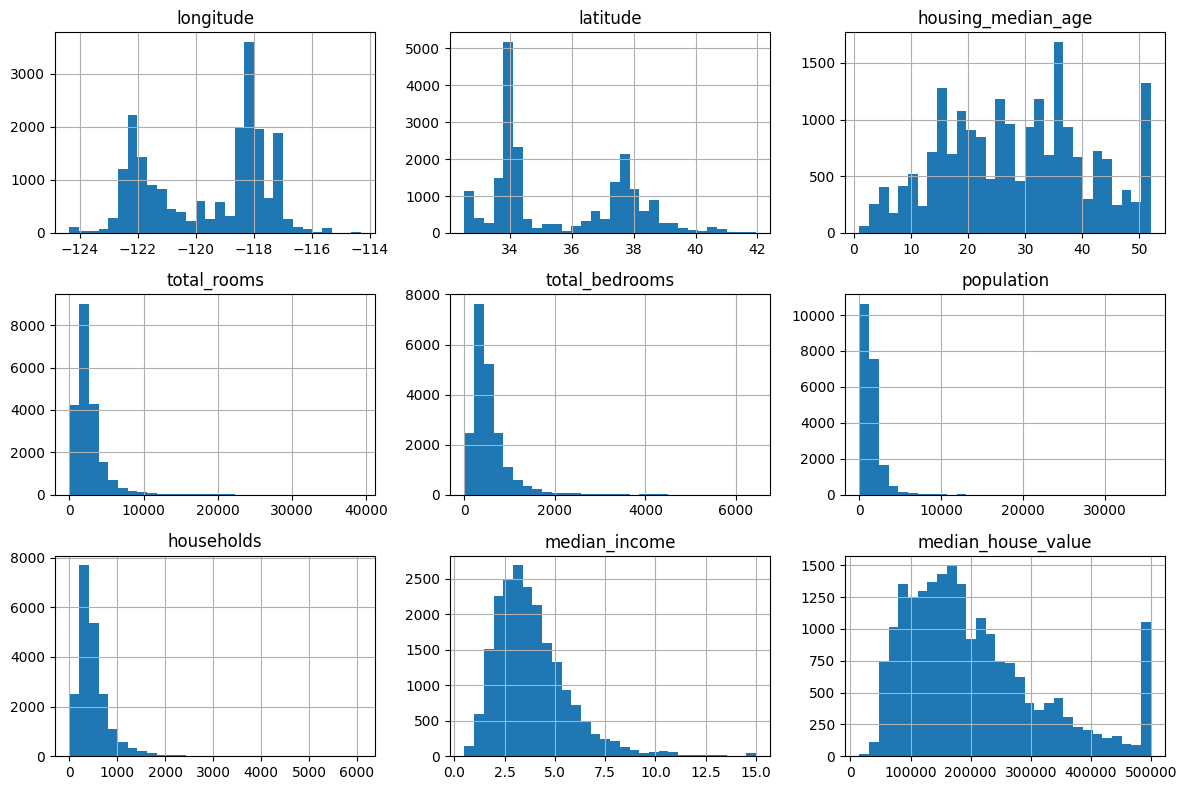

(16512, 10) (4128, 10)


In [3]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print(housing.info())
display(housing.describe().T)
display(housing["ocean_proximity"].value_counts())

housing.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
print(train_set.shape, test_set.shape)


## Practice Tasks

- Describe the dataset: Write a short summary based on head, info, describe, and value_counts.
- Plot for insight: Create a few visualisations and note what they reveal.